# Naive Inflation Rate Prediction 
**Genesis Adam D. Mendoza**

## I. Setting up

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from pmdarima import auto_arima

plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size': 15})

In [2]:
bsp_cpi = pd.read_csv('..//data//bsp_cpibase2018_dataset.csv')
crude_oil = pd.read_csv('..//data//crude_oil_price.csv')
usd_php = pd.read_csv('..//data//usd_to_php.csv')
unemployment = pd.read_csv('..//data//psa_unemployment_rate.csv')

We want to compile the data into a single DataFrame by standardizing each data sources. We will consider the most likely predictors: crude oil price, USD to PHP exchange rate, and unemployment rate.

In [ ]:
bsp_cpi['Date'] = pd.to_datetime(bsp_cpi['Year'].astype(str) + ' ' + bsp_cpi['Month'] + ' 1')
bsp_cpi.rename(columns={'All Items': 'CPI'}, inplace=True)
bsp_cpi = bsp_cpi[['Date', 'CPI']]
bsp_cpi.set_index('Date', inplace = True)
inflation_rate = bsp_cpi['CPI'].pct_change(12) * 100
bsp_cpi['InflationRate'] = inflation_rate

In [4]:
crude_oil['Date'] = pd.to_datetime(crude_oil['Date']).dt.date
crude_oil.rename(columns={'price': 'Value'}, inplace=True)
crude_oil = crude_oil[['Date', 'Value']]
crude_oil.set_index('Date', inplace = True)

In [5]:
usd_php['Period'] = usd_php['Period'].ffill()
usd_php['Date'] = pd.to_datetime(usd_php['Period'].astype(int).astype(str) + ' ' + usd_php['Unnamed: 1'] + ' 1')
usd_php.rename(columns={'Average': 'USDtoPHP'}, inplace=True)
usd_php = usd_php[['Date', 'USDtoPHP']]
usd_php.set_index('Date', inplace = True)

In [6]:
unemployment['Unemployment Rate'] = pd.to_numeric(unemployment['Unemployment Rate'], errors='coerce')
unemployment['Date'] = pd.to_datetime(
    unemployment['Year'].astype(str) + '-' + unemployment['Monthly/Quarterly'] + '-01',
    format='%Y-%B-%d'
)
unemployment = unemployment.drop(columns=['Year', 'Monthly/Quarterly'])
unemployment = unemployment.rename(columns={'Unemployment Rate': 'UnemploymentRate'})
unemployment = unemployment.set_index('Date').sort_index()
unemployment['UnemploymentRate'] = unemployment['UnemploymentRate'].ffill()

In [7]:
cpi_data = pd.concat([crude_oil, usd_php, unemployment, bsp_cpi], axis = 1)
first_valid = cpi_data.dropna().index.min()
last_valid = cpi_data.dropna().index.max()
cpi_data = cpi_data.loc[first_valid:last_valid]
cpi_data = cpi_data.drop(['CPI'], axis = 1)
cpi_data = cpi_data.asfreq('MS')
cpi_data.head()

,Value,USDtoPHP,UnemploymentRate,InflationRate
Date,,,,
2005-01-01,82.68,55.766190,11.40,7.300116
2005-02-01,88.17,54.812842,11.40,7.283237
2005-03-01,93.50,54.440200,11.40,7.142857
2005-04-01,82.62,54.491762,8.28,7.233065
2005-05-01,87.55,54.341095,8.28,7.314286


In [8]:
cpi_data.tail()

,Value,USDtoPHP,UnemploymentRate,InflationRate
Date,,,,
2025-10-01,62.46,58.298409,5.0,1.660079
2025-11-01,59.06,58.913550,4.4,1.496063
2025-12-01,57.74,58.848833,4.4,1.801096
2026-01-01,64.80,59.162190,5.8,2.024922
2026-02-01,66.96,58.280263,5.8,2.419984


## II. Direct prediction through ARIMA 

In [9]:
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('1. ADF: ', result[0])
    print('2. P-value: ', result[1])
    print('3. Num of Lags: ', result[2])
    print('4. Num of Observations: ', result[3])
    print('5. Critial Values:')
    for key, value in result[4].items():
        print('\t', key, ': ', value)
        
    if result[1] <= 0.05:
        print('\nStrong evidence against the null hypothesis (H0), reject the null hypothesis. Data has no unit root and is stationary.')
    else:
        print('\nWeak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary.')

In [10]:
inf_rate = cpi_data['InflationRate']
adf_test(inf_rate.dropna())

1. ADF:  -3.1817848085952214
2. P-value:  0.0210635543125482
3. Num of Lags:  14
4. Num of Observations:  239
5. Critial Values:
	 1% :  -3.458010773719797
	 5% :  -2.8737103617125186
	 10% :  -2.5732559963936206

Strong evidence against the null hypothesis (H0), reject the null hypothesis. Data has no unit root and is stationary.


In [11]:
predictors = cpi_data.copy().drop(['InflationRate'], axis = 1)

months = 6

x_train = predictors[:-months]
y_train = inf_rate[:-months]
x_test = predictors[-months:]
y_test = inf_rate[-months:]

We want to test if the model can forecast the last six months in the data accurately. Get best ARIMA parameters through Auto ARIMA

In [12]:
train_fit = auto_arima(y_train, exogenous=x_train, stepwise=True)
train_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  248
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -138.250
Date:                Fri, 03 Apr 2026   AIC                            284.501
Time:                        20:09:16   BIC                            298.539
Sample:                    01-01-2005   HQIC                           290.153
                         - 08-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2836      0.087     -3.278      0.001      -0.453      -0.114
ar.L2          0.2939      0.074      3.971      0.000       0.149       0.439
ma.L1          0.8989      0.055     16.295      0.000       0.791       1.007
sigma2         0.1789      0.016     11.336      0.000       0.148       0.210
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 2.23
Prob(Q):                              0.79   Prob(JB):                         0.33
Heteroskedasticity (H):               1.32   Skew:                            -0.18
Prob(H) (two-sided):                  0.21   Kurtosis:                         3.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
model = ARIMA(endog=y_train, exog=x_train, order = train_fit.order)
model_fit = model.fit()
print(model_fit.summary())

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:          InflationRate   No. Observations:                  248
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -135.811
Date:                Fri, 03 Apr 2026   AIC                            285.623
Time:                        20:09:16   BIC                            310.188
Sample:                    01-01-2005   HQIC                           295.513
                         - 08-01-2025                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Value                0.0030      0.003      1.114      0.265      -0.002       0.008
USDtoPHP             0.0867      0.040      2.180      0.029       0.009       0.165
UnemploymentRate    -0.0056 

In [14]:
pred = model_fit.forecast(steps=months, exog=x_test)

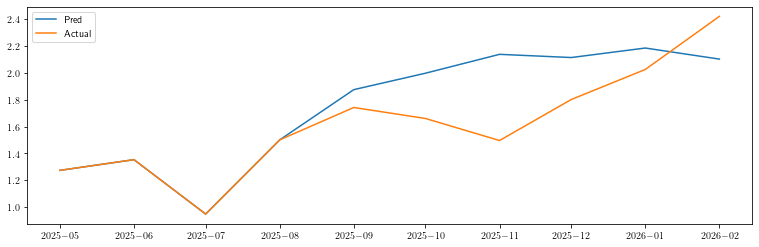

In [15]:
plt.figure(figsize = (13,4))
plt.plot(pd.concat([inf_rate[-10:-months], pred]), label = 'Pred')
plt.plot(inf_rate[-10:], label = 'Actual')
plt.legend()
plt.show()

The model predicts a consistent upward trend and then plateaus. We now want to make predictions for the next three months, namely, March, April, and May. Before that, we can compactify the whole process by creating a function.

In [16]:
def arima_predict(endog, exog, future_exog, period):
    fit = auto_arima(endog, exogenous=exog, stepwise=False, suppress_warnings=True)
    model = ARIMA(endog=endog, exog=exog, order=fit.order)
    model_fit = model.fit()
    pred = model_fit.forecast(steps=period, exog=future_exog)
    return pred

In [17]:
months = 3

endog = inf_rate
exog = predictors

future_index = pd.date_range(start=exog.index[-1] + pd.offsets.MonthBegin(1), periods=months, freq='MS')
future_exog = pd.DataFrame([exog.iloc[-1].values]*months, columns=exog.columns, index=future_index)

predict = arima_predict(endog, exog, future_exog, months)

print(inf_rate.iloc[-1])
print(predict)

2.4199843871975046
2026-03-01    2.820817
2026-04-01    2.893222
2026-05-01    3.015009
Freq: MS, Name: predicted_mean, dtype: float64


The naive model predicted that the inflation rate will speed up for the next three months. 